## Michigan DNR Trail Data Audit

This notebook validates the downloaded Upper Peninsula hiking-trail segments, explore placeholder values so they can be replaced in prep_data.py

In [14]:
from pathlib import Path  # File paths

import pandas as pd  # Tabular data
import geopandas as gpd  # Geospatial data


DATA_PATH = Path("../data/raw/dnr_up_hiking_trails.geojson")
PROCESSED_PATH = Path("../data/processed/dnr_up_hiking_segments_clean.parquet")

trails = gpd.read_file(DATA_PATH)

print(f"Rows: {len(trails):,}")
print(f"Columns: {len(trails.columns)}")
print(f"CRS: {trails.crs}")
trails.head()

Rows: 2,437
Columns: 17
CRS: EPSG:4326


,OBJECTID,DNRTrail,TrailNamePrimary,HikingName,FacilityName,County,Peninsula,Hiking,TrailUseCategory,OpenClosedStatusNonmotor,SurfaceType,TrailWidthFeet,ADAAccessible,SegmentLengthMiles,PublicComments,last_edited_date,geometry
0,1919,DNR Trail,Straits - Main Trail,Straits Main Trail,Straits State Park,Mackinac,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.006157,NaN,1770930791000,"LINESTRING (-84.72138 45.84982, -84.72135 45.8..."
1,2486,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.200800,NaN,1770930791000,"LINESTRING (-87.47649 46.63472, -87.47644 46.6..."
2,2495,DNR Trail,UP 2,North Country Trail,-1,Mackinac,Upper Peninsula,Hiking,Multi Use Motorized Nonmotorized,Open,Dirt Natural,12 Feet And Over,Not Accessible,3.891672,NaN,1780334188000,"LINESTRING (-84.73683 45.87386, -84.73687 45.8..."
3,2540,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.514227,NaN,1770930791000,"LINESTRING (-86.30655 46.48498, -86.30623 46.4..."
4,2541,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.264824,NaN,1770930791000,"LINESTRING (-86.30464 46.48159, -86.30522 46.4..."


In [15]:
trails.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2437 entries, 0 to 2436
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   OBJECTID                  2437 non-null   int32   
 1   DNRTrail                  2437 non-null   str     
 2   TrailNamePrimary          2437 non-null   str     
 3   HikingName                2437 non-null   str     
 4   FacilityName              2437 non-null   str     
 5   County                    2437 non-null   str     
 6   Peninsula                 2437 non-null   str     
 7   Hiking                    2437 non-null   str     
 8   TrailUseCategory          2437 non-null   str     
 9   OpenClosedStatusNonmotor  2437 non-null   str     
 10  SurfaceType               2437 non-null   str     
 11  TrailWidthFeet            2437 non-null   str     
 12  ADAAccessible             2437 non-null   str     
 13  SegmentLengthMiles        2437 non-null 

In [20]:
trails["last_edited_date"] = pd.to_datetime(
    trails["last_edited_date"],
    unit="ms"
)

trails.head()

,OBJECTID,DNRTrail,TrailNamePrimary,HikingName,FacilityName,County,Peninsula,Hiking,TrailUseCategory,OpenClosedStatusNonmotor,SurfaceType,TrailWidthFeet,ADAAccessible,SegmentLengthMiles,PublicComments,last_edited_date,geometry
0,1919,DNR Trail,Straits - Main Trail,Straits Main Trail,Straits State Park,Mackinac,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.006157,NaN,2026-02-12 21:13:11,"LINESTRING (-84.72138 45.84982, -84.72135 45.8..."
1,2486,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.200800,NaN,2026-02-12 21:13:11,"LINESTRING (-87.47649 46.63472, -87.47644 46.6..."
2,2495,DNR Trail,UP 2,North Country Trail,-1,Mackinac,Upper Peninsula,Hiking,Multi Use Motorized Nonmotorized,Open,Dirt Natural,12 Feet And Over,Not Accessible,3.891672,NaN,2026-06-01 17:16:28,"LINESTRING (-84.73683 45.87386, -84.73687 45.8..."
3,2540,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.514227,NaN,2026-02-12 21:13:11,"LINESTRING (-86.30655 46.48498, -86.30623 46.4..."
4,2541,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.264824,NaN,2026-02-12 21:13:11,"LINESTRING (-86.30464 46.48159, -86.30522 46.4..."


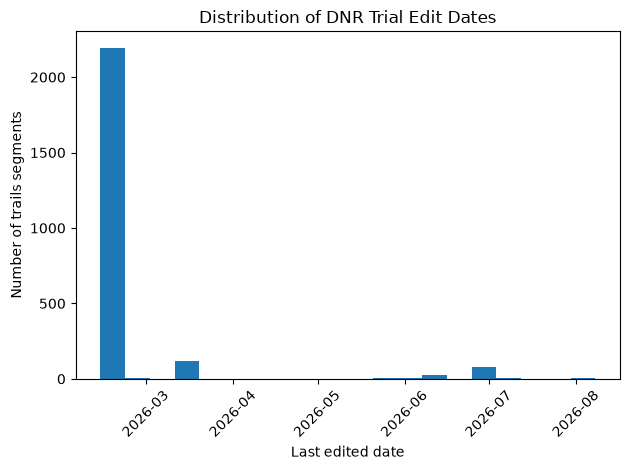

In [24]:
import matplotlib.pyplot as plt

plt.hist(trails["last_edited_date"].dropna(), bins=20)

plt.xlabel("Last edited date")
plt.ylabel("Number of trails segments")
plt.title("Distribution of DNR Trial Edit Dates")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
trails["last_edited_date"].sort_values()

2411   2026-02-12 18:02:11
2287   2026-02-12 20:00:53
2290   2026-02-12 20:00:53
2360   2026-02-12 20:00:53
2359   2026-02-12 20:00:53
               ...        
1458   2026-08-07 18:43:00
1459   2026-08-07 18:43:00
1726   2026-08-07 19:03:08
1377   2026-08-07 19:03:08
498    2026-08-07 19:05:42
Name: last_edited_date, Length: 2437, dtype: datetime64[ms]

In [39]:
(
    (trails["last_edited_date"] == "2026-02-12 20:00:53")
    & (trails["OpenClosedStatusNonmotor"] == "Temporarily Closed")
).sum()

np.int64(0)

In [41]:
mask = (trails["OpenClosedStatusNonmotor"] == "Temporarily Closed")

trails.loc[mask]

,OBJECTID,DNRTrail,TrailNamePrimary,HikingName,FacilityName,County,Peninsula,Hiking,TrailUseCategory,OpenClosedStatusNonmotor,SurfaceType,TrailWidthFeet,ADAAccessible,SegmentLengthMiles,PublicComments,last_edited_date,geometry
1,2486,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.200800,NaN,2026-02-12 21:13:11,"LINESTRING (-87.47649 46.63472, -87.47644 46.6..."
112,3514,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.445860,NaN,2026-02-12 21:13:11,"LINESTRING (-87.49289 46.63979, -87.49189 46.6..."
113,3515,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.259620,NaN,2026-02-12 21:13:11,"LINESTRING (-87.48695 46.64034, -87.48692 46.6..."
114,3516,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.432088,NaN,2026-02-12 21:13:11,"LINESTRING (-87.48435 46.63729, -87.48407 46.6..."
117,3521,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.224164,NaN,2026-02-12 21:13:11,"LINESTRING (-87.46916 46.63441, -87.46845 46.6..."
119,3524,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.786506,NaN,2026-02-12 21:13:11,"LINESTRING (-87.47457 46.63158, -87.47459 46.6..."
2025,12306,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.023261,NaN,2026-02-12 21:13:11,"LINESTRING (-87.47832 46.6062, -87.47822 46.60..."


In [16]:
trails.isna().sum().sort_values(ascending=False)

PublicComments              2431
OBJECTID                       0
DNRTrail                       0
HikingName                     0
TrailNamePrimary               0
County                         0
Peninsula                      0
Hiking                         0
FacilityName                   0
TrailUseCategory               0
OpenClosedStatusNonmotor       0
TrailWidthFeet                 0
SurfaceType                    0
ADAAccessible                  0
SegmentLengthMiles             0
last_edited_date               0
geometry                       0
dtype: int64

In [17]:
unique_counts = (
    trails.nunique(dropna=False)
    .rename("unique_count")
    .reset_index()
    .rename(columns = {"index":"column"})
)

unique_counts

,column,unique_count
0,OBJECTID,2437
1,DNRTrail,1
2,TrailNamePrimary,119
3,HikingName,135
4,FacilityName,25
5,County,15
6,Peninsula,1
7,Hiking,1
8,TrailUseCategory,2
9,OpenClosedStatusNonmotor,4


In [18]:
PLACEHOLDER_VALUES = {
    "",
    "-1",
    "-2",
    "99",
    "-99",
    "Unspecified",
    "Unknown",
    "None",
    "N/A",
    "<NA>",
    "NA"
}

text_columns = trails.select_dtypes(
    include=["object","string"]
).columns

placeholder_records = []

for column in text_columns:
    normalized = trails[column].astype("string").str.strip()
    matches = normalized.isin(PLACEHOLDER_VALUES)

    placeholder_records.append(
        {
            "column": column,
            "placeholder_count": int(matches.sum()),
            "placeholder_percent": round(matches.mean() * 100, 2),
            "values_found": sorted(
                normalized.loc[matches].dropna().unique().tolist()
            ),
        }
    )

placeholder_audit = (
    pd.DataFrame(placeholder_records)
    .sort_values("placeholder_count", ascending=False)
    .reset_index(drop=True)
)

placeholder_audit

,column,placeholder_count,placeholder_percent,values_found
0,FacilityName,658,27.00,"[-1, Unspecified]"
1,TrailWidthFeet,36,1.48,[-1]
2,ADAAccessible,33,1.35,[-99]
3,SurfaceType,13,0.53,[-1]
4,DNRTrail,0,0.00,[]
5,County,0,0.00,[]
6,HikingName,0,0.00,[]
7,TrailNamePrimary,0,0.00,[]
8,Peninsula,0,0.00,[]
9,OpenClosedStatusNonmotor,0,0.00,[]
